# Introduction to Parareal with time-dependent ODE

## Problem of interest

Consider the non-homogeneous Dahlquist problem :

$$
\frac{du}{dt} = \lambda u + \sin(\alpha t), \quad u(t_0) = u_0, \quad t \in [t_0, t_1],
$$

where $\lambda \in \mathbb{C}$ is usually a complex number and $\alpha$ is the frequency of the forcing term.
Under the condition that $\lambda^2 + \alpha^2 \neq 0$ (resonance regime), then the analytical solution of this ordinary differential equation is :

$$
u_{th}(t) = C e^{\lambda t} - \frac{\alpha \cos(\alpha t) + \lambda \sin(\alpha t)}{\alpha^2 + \lambda^2},
$$
where the constant $C$ depends on the initial solution $u_0$:
$$
C = e^{-\lambda t_0}\left[u_0 + \frac{\alpha \cos(\alpha t_0) + \lambda \sin(\alpha t_0)}{\alpha^2 + \lambda^2}\right]
$$

Considering the parameter values $\lambda=1j$ and $\alpha=6$, this corresponds to a solution that oscillates with a period of $2\pi$, with additional oscillations within each period induced by the time-dependent forcing term $\sin(\alpha t)$.
For instance taking $u_0 = 1$, we can plot the solution in the complex plane like this :

<>:21: SyntaxWarning: invalid escape sequence '\R'
<>:21: SyntaxWarning: invalid escape sequence '\I'
<>:21: SyntaxWarning: invalid escape sequence '\R'
<>:21: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/1254149780.py:21: SyntaxWarning: invalid escape sequence '\R'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();
/tmp/ipykernel_6268/1254149780.py:21: SyntaxWarning: invalid escape sequence '\I'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();


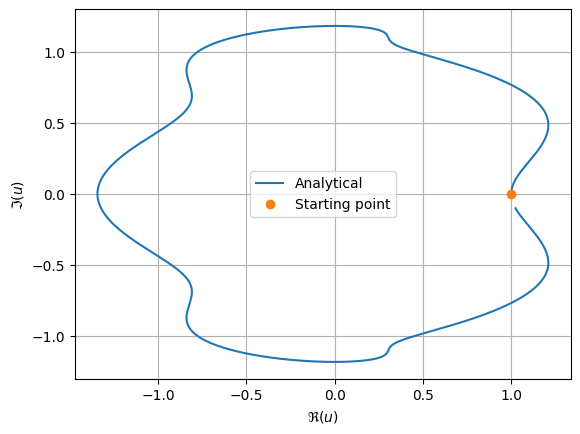

In [133]:
import numpy as np
import matplotlib.pyplot as plt

lam = 1j
alpha = 6

def analytical(u0, t0, t1, nSteps):
    assert lam**2 + alpha**2 != 0, "resonance regime, different analytical solution"
    t = np.linspace(t0, t1, nSteps+1)
    C = np.exp(-lam*t0)*(u0 + (alpha*np.cos(alpha*t0) + lam*np.sin(alpha*t0))/(alpha**2 + lam**2))
    u = C*np.exp(lam*t) - (alpha*np.cos(alpha*t) + lam*np.sin(alpha*t))/(alpha**2 + lam**2)
    return t, u


nSteps = 1000
tEnd = 2*np.pi - 0.1    # small offset to see where the period starts and finishes
t, uTh = analytical(1, 0, tEnd, nSteps)

plt.plot(uTh.real, uTh.imag, label="Analytical")
plt.plot(uTh[0].real, uTh[0].imag, "o", label="Starting point")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

Solution starts at $u_0=1 + 0j$ then has a trajectory going around the origin $0 + 0j$ that comes back to the starting point after $t=2\pi$.
We can also represent it by plotting the real and imaginary parts of $u$ over time : 

<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/3077972549.py:1: SyntaxWarning: invalid escape sequence '\R'
  plt.plot(t, uTh.real, label="$\Re(u)$")
/tmp/ipykernel_6268/3077972549.py:2: SyntaxWarning: invalid escape sequence '\I'
  plt.plot(t, uTh.imag, label="$\Im(u)$")


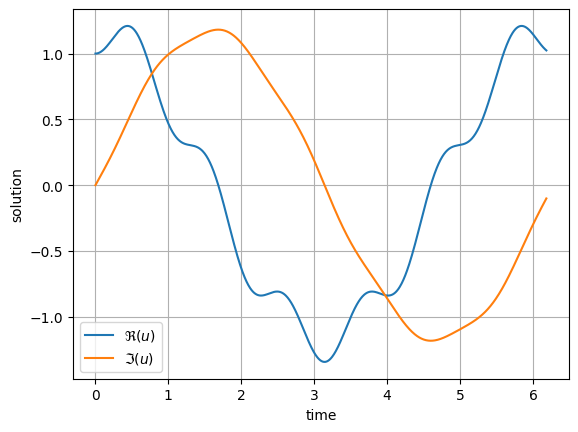

In [134]:
plt.plot(t, uTh.real, label="$\Re(u)$")
plt.plot(t, uTh.imag, label="$\Im(u)$")
plt.legend(), plt.xlabel("time"), plt.ylabel("solution"), plt.grid();

Now, let's try to solve this equation numerically, the same way we would solve a more complex problem to which we cannot compute the analytical solution.
To avoid any numerical stability issue, we can start with the Backward Euler method that compute the solution of a general ODE
$$
\frac{du}{dt} = f(u,t),
$$
on one time-step $u_{i} -\rightarrow u_{i+1}$ using the discrete form of the ODE :
$$
\frac{u_{i+1} - u_{i}}{\Delta t} = f(u_{i+1}, t_{i+1}), \quad \Delta t = t_{i+1} - t_{i}.
$$
In practice, this implies that we have to solve the following equation :
$$
u_{i+1} - \Delta t f(u_{i+1}, t_{i+1}) = u_{i}
$$
where $u_{i}$, $f$ and $t_{i+1}$ are known, and $u_{i+1}$ is the unknown.
In our case (non-homogeneous Dahlquist), $f(u,t) = \lambda u + \sin(\alpha t)$ has a simpler form, so we can write it directly as :
$$
u_{i+1} - \Delta t (\lambda u_{i+1} + \sin(\alpha t_{i+1})) = u_{i} \Rightarrow u_{i+1} = \frac{u_{i} + \Delta t \sin(\alpha t_{i+1})}{1 - \Delta t \lambda},
$$
which can be explicitly computed.
Then, since we usually need to compute several time-step for the full simulation time-interval $[t_0, t_1]$, we can define the time-stepper function that solves the ODE numerically with `nSteps` time-steps like this :

In [135]:
def timeStepper(u0, t0, t1, nSteps):
    dt = (t1-t0)/nSteps
    t = np.linspace(t0, t1, nSteps+1)
    u = lam * np.zeros_like(t)

    u[0] = u0
    for i in range(nSteps):
        u[i+1] = (u[i] + dt*np.sin(alpha*t[i+1]))/(1-dt*lam)

    return t, u

Computing for instance with `nSteps=1000` and comparing with the analytical solution gives : 

<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\I'
<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/2520810359.py:7: SyntaxWarning: invalid escape sequence '\R'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();
/tmp/ipykernel_6268/2520810359.py:7: SyntaxWarning: invalid escape sequence '\I'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();


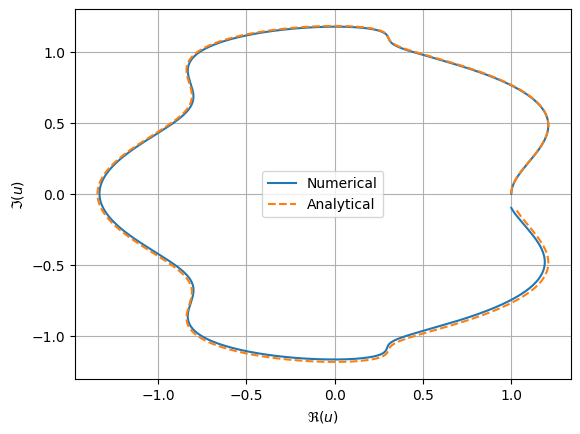

In [136]:
nSteps = 1000
# tEnd is already defined above ...
t, uNum = timeStepper(1, 0, tEnd, nSteps)

plt.plot(uNum.real, uNum.imag, label="Numerical")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

$\Rightarrow$ we observe a small discrepancy between numerical and analytical solution, due to the discretization error of Backward Euler.
This can be reduced by computing on more time-steps, like ten times more :

<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\I'
<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/4234407574.py:7: SyntaxWarning: invalid escape sequence '\R'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();
/tmp/ipykernel_6268/4234407574.py:7: SyntaxWarning: invalid escape sequence '\I'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();


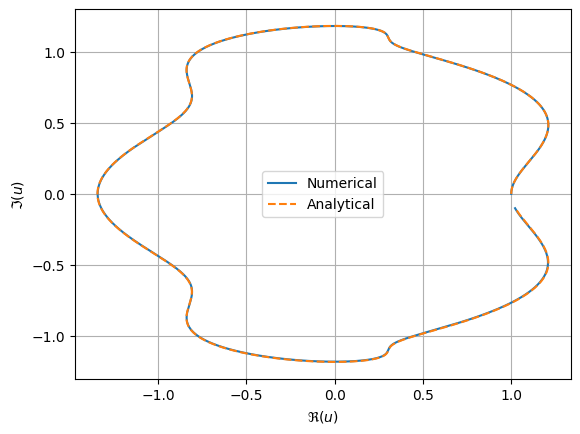

In [137]:
nSteps = 10000
# tEnd is already defined above ...
t, uNum = timeStepper(1, 0, tEnd, nSteps)

plt.plot(uNum.real, uNum.imag, label="Numerical")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

Usually, it's interesting to look at the evolution of the error w.r.t the number of time-steps, for instance like this (with log-log plots):

0.0025072138211199237


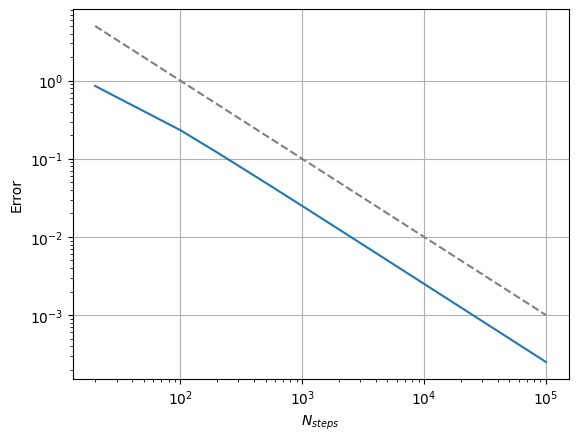

In [246]:
nStepsVals = np.array([20, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 100000])

errors = []
for nSteps in nStepsVals:
    _, uTh = analytical(1, 0, tEnd, nSteps)
    _, uNum = timeStepper(1, 0, tEnd, nSteps)
    errors.append(np.linalg.norm(uNum-uTh, ord=np.inf))     # use the L_infty norm to get the maximum absolute value difference 

plt.loglog(nStepsVals, errors)
plt.loglog(nStepsVals, 1e2/nStepsVals, "--", c="gray")
plt.xlabel("$N_{steps}$"), plt.ylabel("Error"), plt.grid();
print(errors[7])

$\Rightarrow$ we can see that the log of the error decrease linearly with the log of $N_{steps}$, which is characteristic from the first order accuracy of the Backward Euler time integration and assert that we implemented it correctly.

## Standard Parareal

You can use the base implementation of Parareal provided [here](https://github.com/Parallel-in-Time/book-pint-code/blob/gaia/chap2/sec2.3/Parareal.py), and generally the application examples provided [here](https://github.com/Parallel-in-Time/book-pint-code/blob/gaia/chap2/README.md#section-23--the-parareal-algorithm).

> 💡 What is called "coarse time-points" with Parareal are the interfaces of each time-windows. 
 
Use it on the Dahlquist problem defined above, considering $N=10$ time-windows, a fine solver $\mathcal{F}$ that uses $N_{steps,F}$ time-steps per period to compute solution, and a coarse solver $\mathcal{G}$ that uses $N_{steps,G} < N_{steps,F}$ time-steps per period.
We denote by **Parareal error** the one between the Parareal solution and the sequential solution (computed without Parareal).
First, look at :

- maximum Parareal error for all coarse points VS iteration number 
- Parareal error VS time for different iterations number

$\Rightarrow$ you should see the "systematic" convergence of Parareal that assess that it's correctly implemented.

Then, there is a small optimization problem to find the "optimal" Parareal configuration :

1. you know the discretization error of the fine sequential solution (thanks to the comparison with analytical solution) : $e_{discr}$
2. you can estimate the cost of your fine solver by counting the number of stages that has to be done in parallel, i.e :
$$
C_{seq} = N N_{steps,F}
$$
3. you can estimate the cost of Parareal in function of the number of iterations $K$ and the number of time-steps $N_{steps,G}$ for the coarse solver using the distributed implementation of Parareal from [Aubanel](https://doi.org/10.1016/j.parco.2010.10.004) :
$$
C_{Parareal} = N N_{steps,G} + K(N_{steps,F} + N_{steps,G})
$$ 
4. you can retrieve from it the parallel speedup of Parareal :
$$
S = \frac{C_{seq}}{C_{Parareal}} = \frac{N}{Nr + K(1+r)}, \quad r := \frac{N_{steps,G}}{N_{steps,F}}
$$
5. for one given $N_{steps,G}$, you can compute how much iterations $K$ are needed to put the error of Parareal below $e_{discr}$

$\Rightarrow$ which value $N_{steps,G}$ maximizes the speedup of Parareal given enough iteration are done to ensure point n°5 ?

### Parareal solver

In [182]:
def parareal(F, G, T, u0, N, K):
    """
    Implements the Parareal algorithm.

    Parameters
    ----------
    F : callable
        Fine solver, F(t0, t1, u0), advancing from t0 to t1 with initial condition u0.
    G : callable
        Coarse solver, G(t0, t1, u0), advancing from t0 to t1 with initial condition u0.
    T : float
        Final time.
    u0 : array-like
        Initial condition at t = 0.
    N : int
        Number of equidistant coarse time points.
    K : int
        Number of Parareal iterations.

    Returns
    -------
    U : list of numpy.ndarray
        List where U[k] contains the Parareal approximations at the coarse time points for each iteration k.
    """
    #u0 = np.asarray(u0)
    TT = np.linspace(0, T, N+1)         # Coarse time mesh
    
    U = np.zeros((K+1, N+1), dtype=complex)  # Parareal approximations for each iteration and time point

    U[:, 0] = u0        # Initial condition (for all iterations)

    for n in range(N):  # Initial guess
         U[0, n+1] = G(TT[n], TT[n + 1], U[0, n])

    for k in range(K):  # Parareal iterations
        for n in range(N):
            U[k+1, n+1] = F(TT[n], TT[n+1], U[k, n]) \
                + G(TT[n], TT[n+1], U[k+1, n]) - G(TT[n], TT[n+1], U[k, n])

    return np.squeeze(U)


#### Fine and coarse solvers

In [338]:
MF = 100 # Fine solver's time steps
MG = 2 # Coarse solver's time steps
F = lambda t0, t1, u0: timeStepper(u0, t0, t1, MF)[-1][-1] # fine solver
G = lambda t0, t1, u0: timeStepper(u0, t0, t1, MG)[-1][-1] # Coarse solver
K = 4 # Parareal iterations
u0 = 1+0j
T = tEnd
N = 10 # nWidows
U = parareal(F, G, T, u0, N, K)
t, U_exact = timeStepper(u0, 0, T, MF*N)
TT = np.linspace(0,tEnd,N+1)

TypeError: unsupported operand type(s) for *: 'function' and 'float'

- Maximum Parareal error for all coarse points VS iteration number 

0.011402439277619237


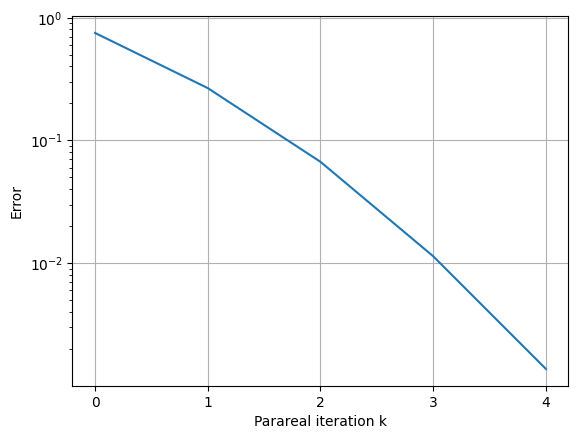

In [314]:
errors_para = []
for k in range(K+1):
    errors_para.append(np.linalg.norm(U[k]-U_exact[::MF],ord=np.inf))
plt.semilogy(range(K+1), errors_para)
plt.xticks(range(K+1))
plt.xlabel("Parareal iteration k"), plt.ylabel("Error"), plt.grid(); 
print(errors_para[3]) 

- Parareal error VS time for different iterations number

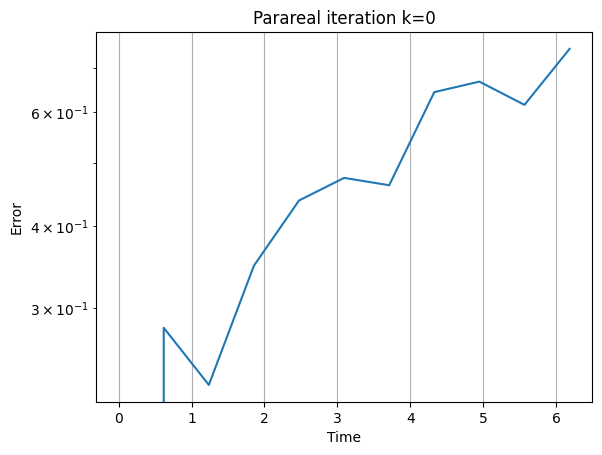

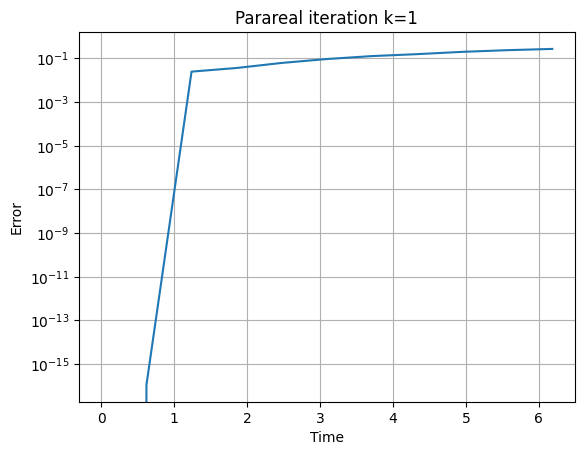

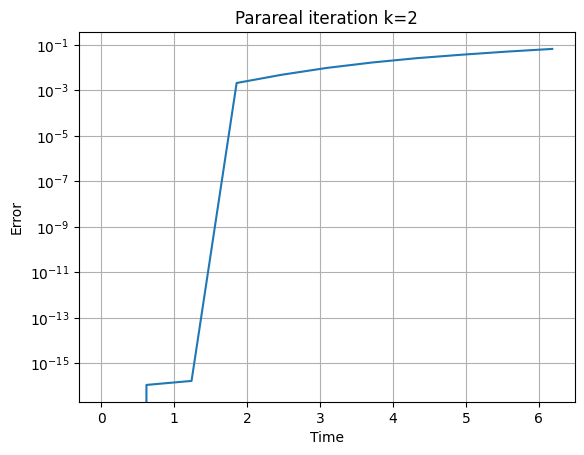

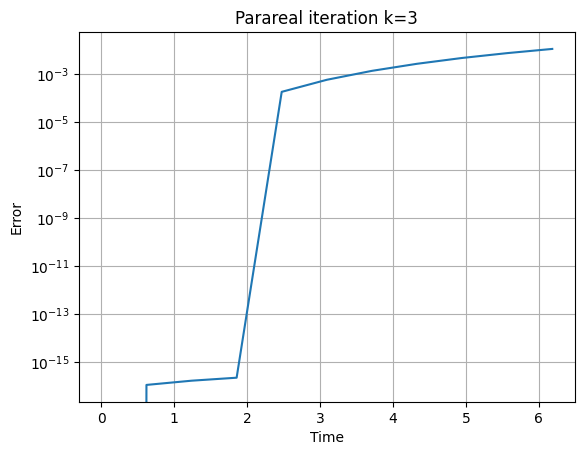

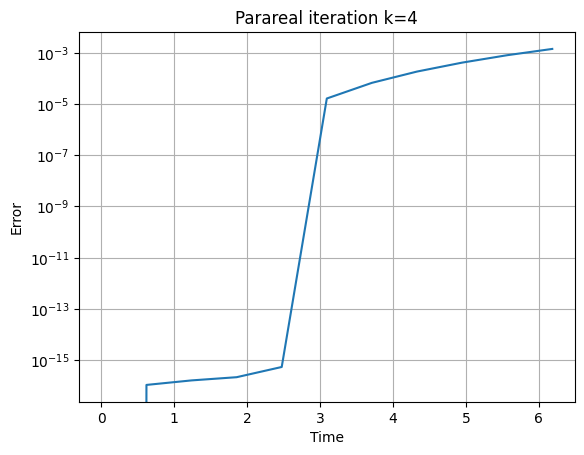

In [315]:
for k in range(K+1):
    fig = plt.figure()
    t_error=(np.abs(U[k] - U_exact[::MF]))
    plt.semilogy(TT, t_error)
    plt.xlabel("Time"), plt.ylabel("Error")
    plt.title(f"Parareal iteration k={k}")
    plt.grid()
plt.show()

- Optimization problem

In [316]:
# for the previous setup...
C_para = N*MG + K*(MF+MG) 
C_seq       = N*MF
print(f"{'N_steps':>10} | {'discretization_error':>22}")
print("-" * 36)
for n, e in zip(nStepsVals, errors):
    print(f"{int(n):10d} | {e:22.6e}")
S = C_seq/C_para
r = MG/MF
idx = np.where(nStepsVals == C_seq)[0]
if idx.size > 0:
    idx = idx[0]
    print(f"For N_steps={C_seq} the discretization error is {errors[idx]:.6e}")
else:
    print(f"N_steps={C_seq} not found in nStepsVals")

print(f"For {K} Parareal iterations with MF={MF} and MG={MG} the error is {errors_para[K]:.6e}")
print(f"Speedup S = {S:.2f}, r = {r:.2f}")

   N_steps |   discretization_error
------------------------------------
        20 |           8.553822e-01
       100 |           2.324179e-01
       200 |           1.208261e-01
       500 |           4.943600e-02
      1000 |           2.490391e-02
      2000 |           1.249863e-02
      5000 |           5.010681e-03
     10000 |           2.507214e-03
     20000 |           1.254075e-03
    100000 |           2.508901e-04
For N_steps=1000 the discretization error is 2.490391e-02
For 4 Parareal iterations with MF=100 and MG=2 the error is 1.379237e-03
Speedup S = 2.34, r = 0.02


Maximum speedup for MG in range [1, MF]: 5.32 at MG = 8 with K_min = 1
Error for : 2.490391e-02
Parareal error for MG = 8 with minimal number of iterations K = 1 is 2.217188e-02


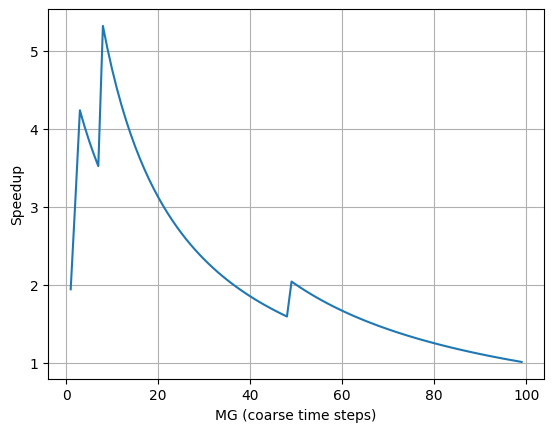

In [312]:
N           = 10 # time windows - coarse time grid
MF          = 100 # Fine time steps
K           = N
C_seq       = N*MF # 1000 nSteps
u0          = 1+0j
T           = tEnd
F           = lambda t0, t1, u0: timeStepper(u0, t0, t1, MF)[-1][-1]
_,UNum      = timeStepper(u0, 0, T, MF*N)
_, UTh      = analytical(u0, 0, T, MF*N)
err_disc    = np.linalg.norm(UNum-UTh, ord=np.inf)

S           = []
Kmins       = []
err_para    = []

for MG in range(1, MF):
    G       = lambda t0, t1, u0: timeStepper(u0, t0, t1, MG)[-1][-1]
    U       = parareal(F, G, T, u0, N, K)
    k_min   = None
    for k in range(K+1):
        err_p = np.linalg.norm(U[k]-UNum[::MF],ord=np.inf)
        if err_p <= err_disc:
            k_min = k
            break
    C_para = N*MG + k_min*(MF+MG) 
    S.append(C_seq/C_para)
    Kmins.append(k_min)
    err_para.append(err_p)

idx_best = int(np.argmax(S))

print(f"Maximum speedup for MG in range [1, MF]: {max(S):.2f} at MG = {idx_best+1} with K_min = {Kmins[idx_best]}")
print(f"Error for : {err_disc:.6e}")
print(f"Parareal error for MG = {idx_best+1} with minimal number of iterations K = {Kmins[idx_best]} is {err_para[idx_best]:.6e}")

plt.plot(range(1, MF), S)
plt.xlabel("MG (coarse time steps)"), plt.ylabel("Speedup"), plt.grid()     
plt.show()

## Adaptive Parareal

Before going to a battery model, we can consider the modified non-homogeneous Dahlquist problem :

$$
\frac{du}{dt} = \lambda(t) u + \sin(\alpha t), \quad u(t_0) = u_0, \quad t \in [t_0, t_1],
$$

where $\lambda(t) = 1j(1+\epsilon(t))$ and $\epsilon(t)$ a small variation that varies after one period (i.e when $\Im(u)$ reaches 0 for the second time).
Since the period is $T=2\pi\lambda(t)$, this will emulate a pseudo-periodic problem and the idea is to implement the Parareal algorithm such that is works on this.

> First, we can consider a step function for $\epsilon(t) = 0.01 n$ where $n$ is the index of the time-windows.

<>:33: SyntaxWarning: invalid escape sequence '\R'
<>:33: SyntaxWarning: invalid escape sequence '\I'
<>:33: SyntaxWarning: invalid escape sequence '\R'
<>:33: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/1100892111.py:33: SyntaxWarning: invalid escape sequence '\R'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();
/tmp/ipykernel_6268/1100892111.py:33: SyntaxWarning: invalid escape sequence '\I'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();


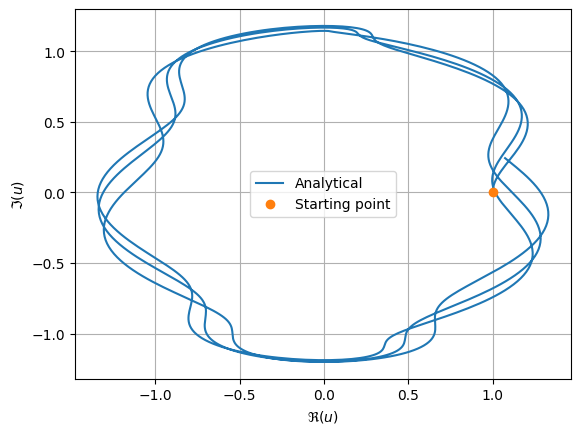

In [317]:
# follow the same procedure from before...

Period = 2*np.pi/(1.01)
nPeriods = 3
tEnd = nPeriods*Period
eps = lambda n: 0.01*n
lam = lambda n: 1j*(1 + eps(n))
alpha = 6.001   # to avoid resonance regime
u0 = 1+0j

# Analytical solution on every time window nW
def analytical_n(nW, u0, t0, t1):
    assert lam(nW)**2 + alpha**2 != 0, "resonance regime, different analytical solution"
    C = np.exp(-lam(nW)*t0)*(u0 + (alpha*np.cos(alpha*t0) + lam(nW)*np.sin(alpha*t0))/(alpha**2 + lam(nW)**2))
    u = C*np.exp(lam(nW)*t1) - (alpha*np.cos(alpha*t1) + lam(nW)*np.sin(alpha*t1))/(alpha**2 + lam(nW)**2)
    return u

# Analytical solution on the whole time interval 
def analytical_n_vec(u0, t0, t1, nSteps):
    t = np.linspace(t0, t1, nSteps+1)
    u = np.zeros_like(t, dtype=complex)
    u[0] = u0
    for nP in range(1, nPeriods+1):
        assert lam(nP)**2 + alpha**2 != 0, "resonance regime, different analytical solution"
        for i in range(len(t)-1):
            nP = int(t[i]//Period) + 1
            assert lam(nP)**2 + alpha**2 != 0, "resonance regime, different analytical solution"
            u[i+1] = analytical_n(nP, u[i], t[i], t[i+1])
    return t, u

nSteps = 1000
t, uTh = analytical_n_vec(u0, 0, tEnd, nSteps)
plt.plot(uTh.real, uTh.imag, label="Analytical")
plt.plot(uTh[0].real, uTh[0].imag, "o", label="Starting point")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/3077972549.py:1: SyntaxWarning: invalid escape sequence '\R'
  plt.plot(t, uTh.real, label="$\Re(u)$")
/tmp/ipykernel_6268/3077972549.py:2: SyntaxWarning: invalid escape sequence '\I'
  plt.plot(t, uTh.imag, label="$\Im(u)$")


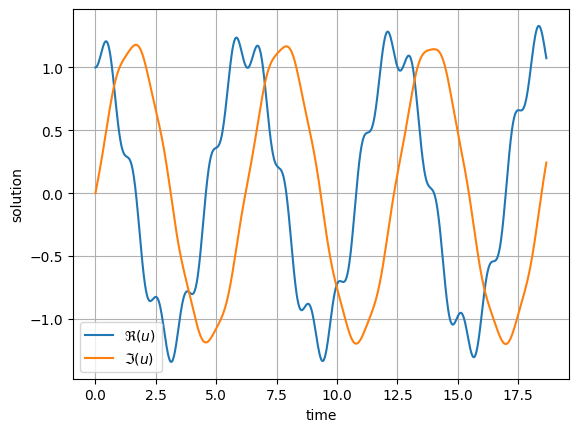

In [318]:
plt.plot(t, uTh.real, label="$\Re(u)$")
plt.plot(t, uTh.imag, label="$\Im(u)$")
plt.legend(), plt.xlabel("time"), plt.ylabel("solution"), plt.grid();

In [319]:
def timeStepperModiefied(u0, t0, t1, nSteps):
    dt = (t1-t0)/nSteps
    t = np.linspace(t0, t1, nSteps+1)
    u = np.zeros_like(t,dtype=complex)
    u[0] = u0
    for i in range(nSteps):
        nP = int(t[i]//Period) + 1
        u[i+1] = (u[i] + dt*np.sin(alpha*t[i+1]))/(1-dt*lam(nP))
    return t, u

<>:6: SyntaxWarning: invalid escape sequence '\R'
<>:6: SyntaxWarning: invalid escape sequence '\I'
<>:6: SyntaxWarning: invalid escape sequence '\R'
<>:6: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_6268/2702257506.py:6: SyntaxWarning: invalid escape sequence '\R'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();
/tmp/ipykernel_6268/2702257506.py:6: SyntaxWarning: invalid escape sequence '\I'
  plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();


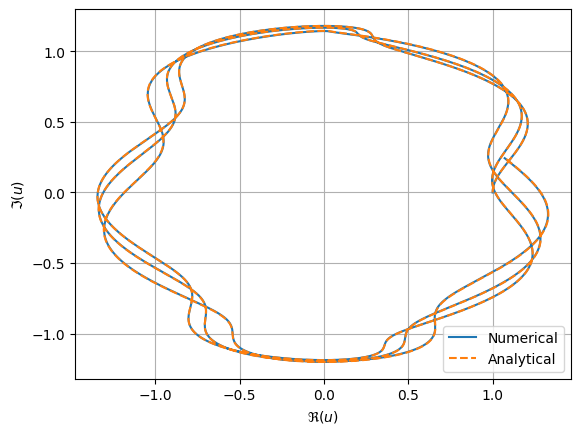

In [320]:
nSteps = 100000
t, uNum = timeStepperModiefied(u0, 0, tEnd, nSteps)

plt.plot(uNum.real, uNum.imag, label="Numerical")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.legend(), plt.xlabel("$\Re(u)$"), plt.ylabel("$\Im(u)$"), plt.grid();

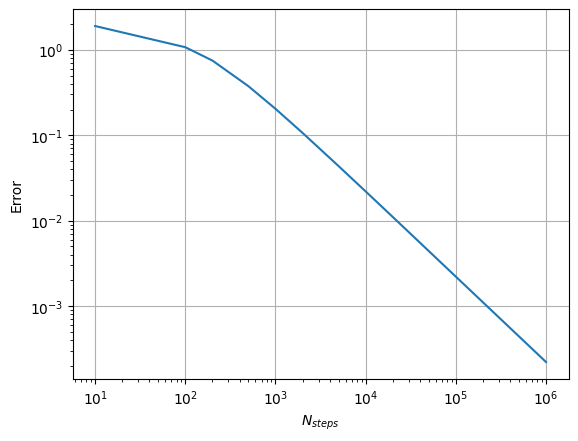

In [330]:
nStepsVals = np.array([10, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 1000000])

errors = []
for nSteps in nStepsVals:
    _, uTh = analytical_n_vec(u0, 0, tEnd, nSteps)
    _, uNum = timeStepperModiefied(u0, 0, tEnd, nSteps)
    errors.append(np.linalg.norm(uNum-uTh, ord=np.inf))     # use the L_infty norm to get the maximum absolute value difference 

plt.loglog(nStepsVals, errors)
#plt.loglog(nStepsVals, 1e3/nStepsVals, "--", c="gray")

plt.xlabel("$N_{steps}$"), plt.ylabel("Error"), plt.grid();

# linear behavior ..


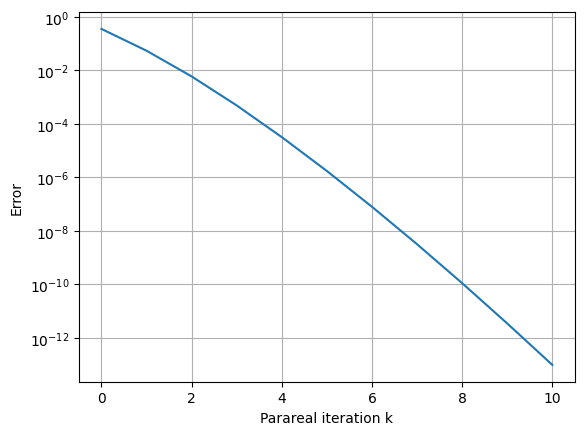

In [361]:
MF = 100# Fine time steps
MG = 5# Coarse time steps
F = lambda t0, t1, u0: timeStepperModiefied(u0, t0, t1, MF)[-1][-1]
G = lambda t0, t1, u0: timeStepperModiefied(u0, t0, t1, MG)[-1][-1]
K = 10 # iteration of Parareal
N = 100 # nWindows - coarse time grid for all periods
U = parareal(F, G, tEnd, u0, N, K)
t, U_exact =timeStepperModiefied(u0, 0, tEnd, MF*N)

#Error
errors_para = []
for k in range(K+1):
    errors_para.append(np.linalg.norm(U[k]-U_exact[::MF],ord=np.inf))
plt.semilogy(range(K+1), errors_para)
plt.xlabel("Parareal iteration k"), plt.ylabel("Error"), plt.grid();   

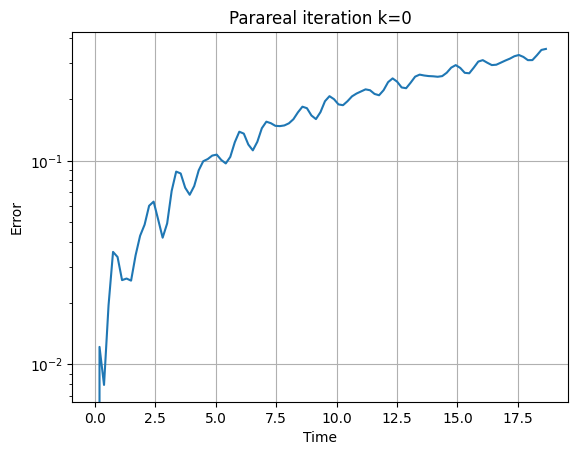

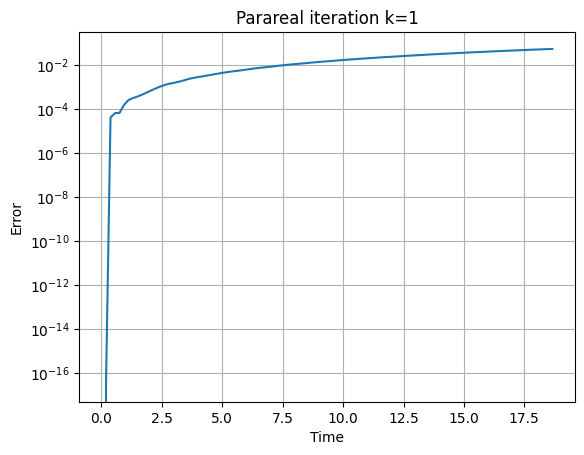

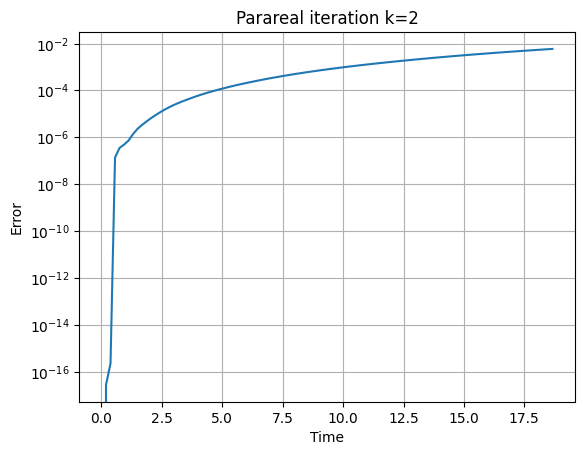

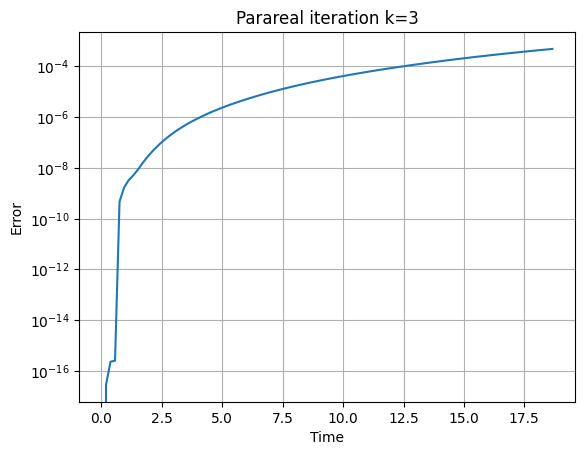

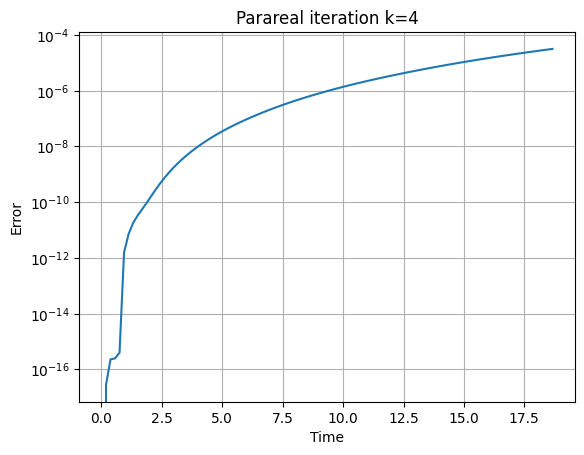

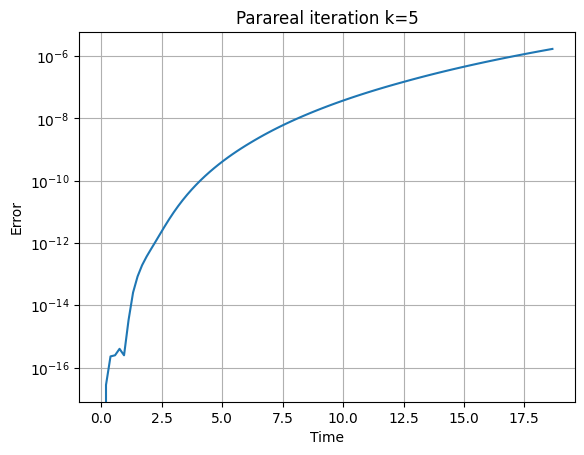

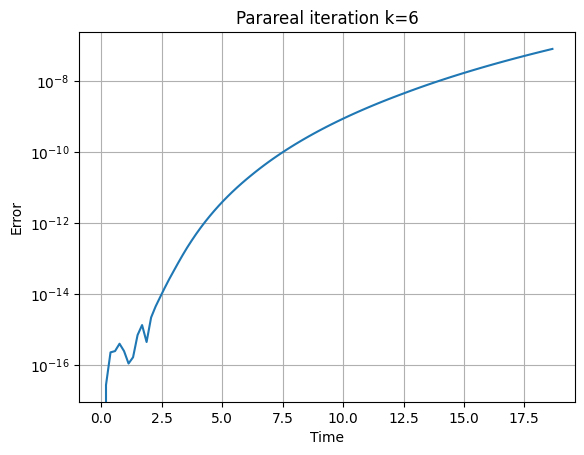

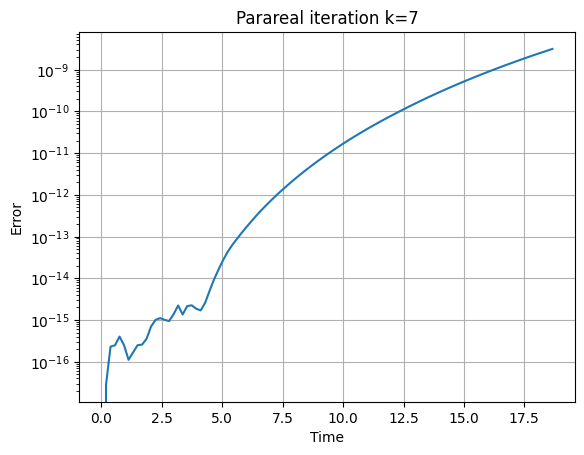

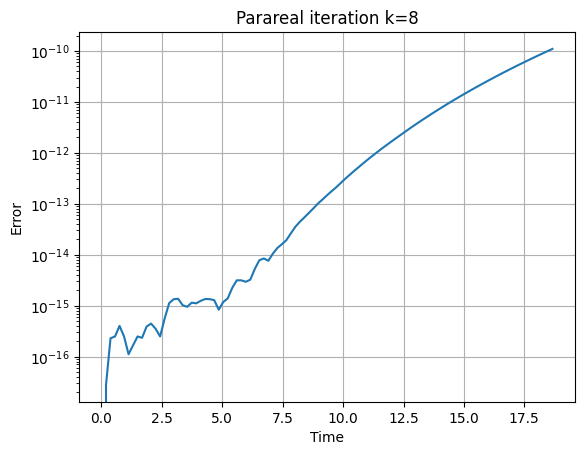

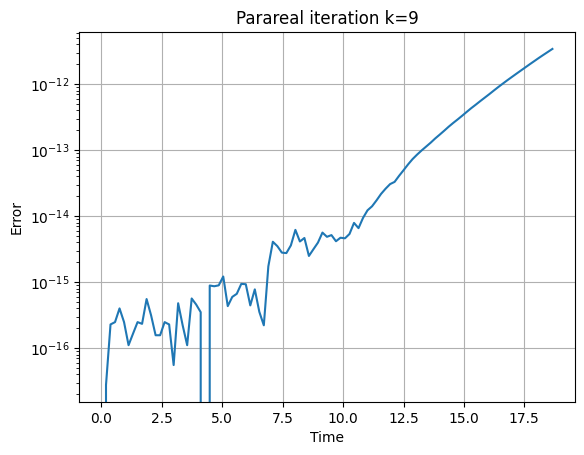

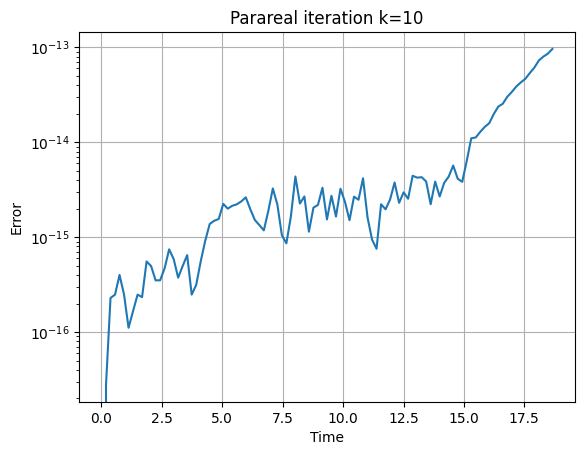

In [362]:
TT = np.linspace(0,tEnd,N+1)
for k in range(K+1):
    fig = plt.figure()
    t_error=(np.abs(U[k] - U_exact[::MF]))
    plt.semilogy(TT, t_error)
    plt.xlabel("Time"), plt.ylabel("Error")
    plt.title(f"Parareal iteration k={k}")
    plt.grid()
plt.show()

In [ ]:
# for the previous setup...
C_para = N*MG + K*(MF+MG) 
C_seq       = N*MF
print(f"{'N_steps':>10} | {'discretization_error':>22}")
print("-" * 36)
for n, e in zip(nStepsVals, errors):
    print(f"{int(n):10d} | {e:22.6e}")
S = C_seq/C_para
r = MG/MF
idx = np.where(nStepsVals == C_seq)[0]
if idx.size > 0:
    idx = idx[0]
    print(f"For N_steps={C_seq} the discretization error is {errors[idx]:.6e}")
else:
    print(f"N_steps={C_seq} not found in nStepsVals")

print(f"For {K} Parareal iterations with MF={MF} and MG={MG} the error is {errors_para[K]:.6e}")
print(f"Speedup S = {S:.2f}, r = {r:.2f}")

   N_steps |   discretization_error
------------------------------------
        10 |           1.898068e+00
       100 |           1.071954e+00
       200 |           7.479653e-01
       500 |           3.756798e-01
      1000 |           2.038440e-01
      2000 |           1.062774e-01
      5000 |           4.360525e-02
     10000 |           2.198934e-02
     20000 |           1.104175e-02
   1000000 |           2.217632e-04
For N_steps=10000 the discretization error is 2.198934e-02
For 10 Parareal iterations with MF=100 and MG=5 the error is 9.640202e-14
Speedup S = 6.45, r = 0.05
Cost of Parareal is C_para=1550


Maximum speedup for MG in range [1, MF]: S = 19.76 at MG = 2 with K_min = 3
For N_steps = 10000 discretization error is : 2.198934e-02
Parareal error for MG = 2 with minimal number of iterations K = 3 is 1.414937e-02


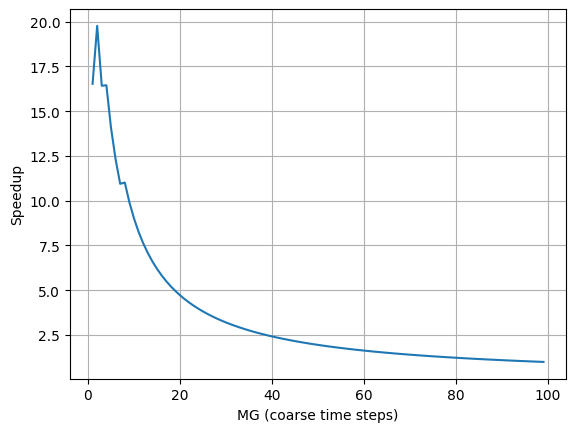

In [360]:
N  = 100    # nWindows - coarse grid
MF = 100    # fine solver's nSteps
K = N       # Parareal iterations
C_seq       = N*MF
T           = tEnd
_,UNum      = timeStepperModiefied(u0, 0, T, MF*N)
_, UTh      = analytical_n_vec(u0, 0, T, MF*N)
err_disc    = np.linalg.norm(UNum-UTh, ord=np.inf)

S           = []
Kmins       = []
err_para    = []

for MG in range(1, MF): # (1, 100) coarse solver nSteps
    G       = lambda t0, t1, u0: timeStepperModiefied(u0, t0, t1, MG)[-1][-1]
    k_min   = None
    for k in range(K+1): # (0, N) Parareal iterations
        U       = parareal(F, G, T, u0, N, k)
        err_p = np.linalg.norm(U[k]-UNum[::MF],ord=np.inf)
        if err_p <= err_disc:
            k_min = k
            break
    C_para = N*MG + k_min*(MF+MG) 
    S.append(C_seq/C_para)
    Kmins.append(k_min)
    err_para.append(err_p)

idx_best = int(np.argmax(S))

print(f"Maximum speedup for MG in range [1, MF]: S = {max(S):.2f} at MG = {idx_best+1} with K_min = {Kmins[idx_best]}")
print(f"For N_steps = {C_seq} discretization error is : {err_disc:.6e}")
print(f"Parareal error for MG = {idx_best+1} with minimal number of iterations K = {Kmins[idx_best]} is {err_para[idx_best]:.6e}")
plt.plot(range(1, MF), S)
plt.xlabel("MG (coarse time steps)"), plt.ylabel("Speedup"), plt.grid()     
plt.show()